# Linear Regression Projects

## Simple Linear Regression

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

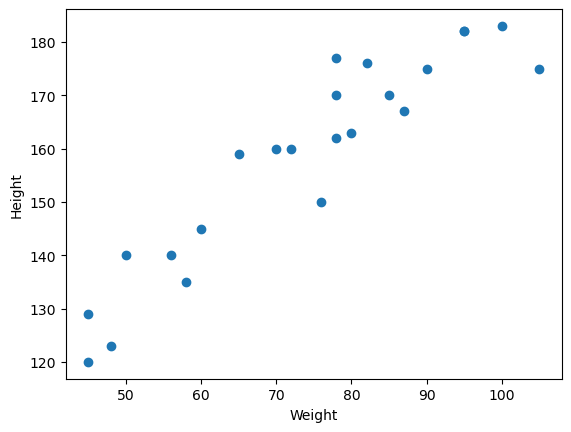

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [4]:
##Divide the dataset into dependent and independent features
X=df[['Weight']] ## independent features (Must be a dataframe)
y=df['Height'] ## dependent features (Must be series)

In [6]:
## splitting the data for training and testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [7]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

##### Standardizing helps to put the features in single scale (a smaller scale)
Because if we dont, we will have situations where when we have bigger values the errors will be bigger which will make it very difficult to optimize or converge to the gradient descent(reducing the cost function)

Its not all algorithms that need standardization. We use it wherever there is distance based algorithm, or optimization kind of algorithm. 

In linear regression standardization needs to be applied.

In [8]:
## Standardize the independent feature (X_data)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) ## gets the mean and std of the X_train data and perfoms the z-score for all data points
## To prevent data leakage we ensure we use transform() instead for the X_test. This will use the mean and std deviation od the X_train to perform the z-score
X_test_scaled=scaler.transform(X_test)

In [9]:
## train the model
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)

LinearRegression()

In [11]:
regression.coef_, regression.intercept_

(array([17.03440872]), 157.5)

In [12]:
y_train_pred=regression.predict(X_train_scaled)

Text(0, 0.5, 'y_train')

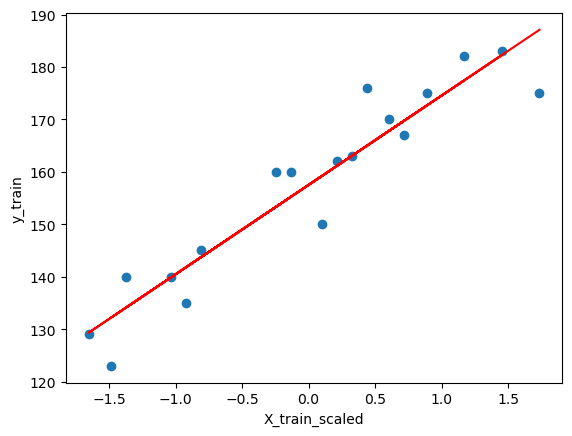

In [18]:
## Let us view the model in the training model

plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,y_train_pred, c='r')
plt.xlabel('X_train_scaled')
plt.ylabel('y_train')

In [19]:
y_test_pred=regression.predict(X_test_scaled)

Text(0, 0.5, 'y_test')

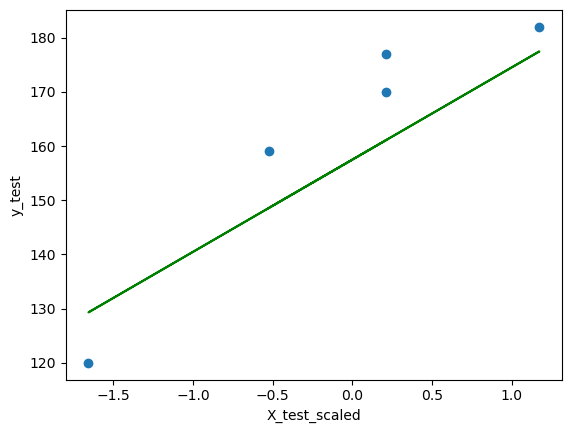

In [20]:
## Let us view the model in the test data

plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled,y_test_pred, c='g')
plt.xlabel('X_test_scaled')
plt.ylabel('y_test')

In [22]:
## Performance metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [24]:
mse=mean_squared_error(y_test,y_test_pred)
mae=mean_absolute_error(y_test,y_test_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_test_pred)

mse,mae,rmse,score

(109.77592599051654, 9.822657814519227, 10.477400726827076, 0.7769869860423441)

In [25]:
## Adjusted r-square
adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1)
adjusted_score

0.7026493147231254

In [26]:
## predicting new inputs eg weight = 80
height=regression.predict(scaler.transform([[80]]))
height
                        

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([163.01076266])

#### The Assumptions

When can you say you have trained a very good model.


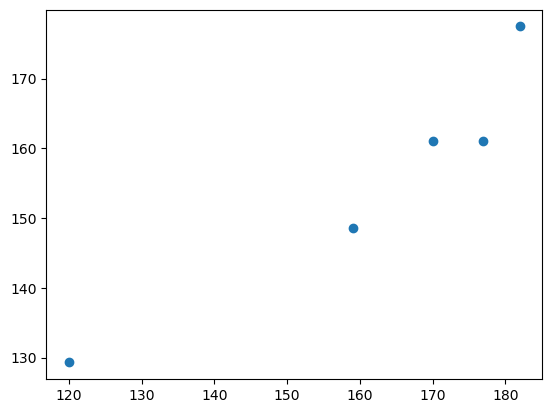

In [28]:
## Plot the scatter plot of the y_test and y_pred.
## If they has a linear relationship then the model is good

plt.scatter(y_test,y_test_pred)

C:\Users\pc\AppData\Local\Temp\ipykernel_21476\392450039.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

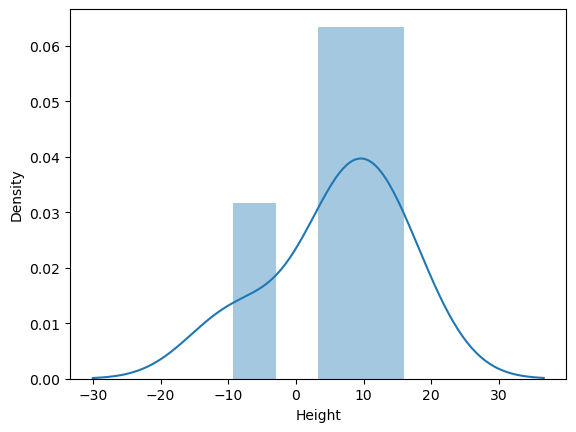

In [29]:
## Residuals
## If the residuals are normally distributed then the model is good

residuals=y_test-y_test_pred
sns.distplot(residuals,kde=True)

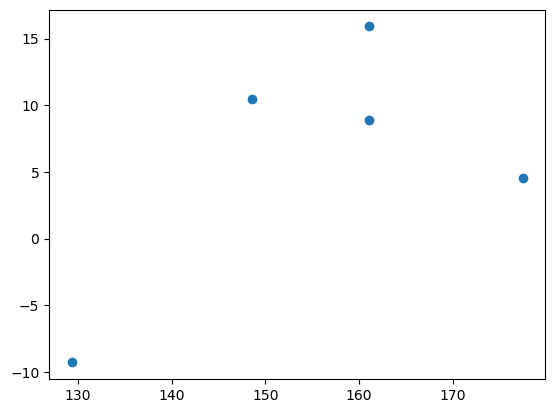

In [30]:
## Plot a scatter plot between the residuals and the predicted values
## If they are uniformly distributed(no relationship) then the model is good

plt.scatter(y_test_pred, residuals)

## Multiple Linear Regression

For this we will use an sklearn dataset fetch_california_housing for california pricing

In [88]:
from sklearn.datasets import fetch_california_housing

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [90]:
california_data = fetch_california_housing()
california_data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [91]:
california_data.keys() ## This data is a kind of dictonary

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [92]:
## lets view the description
print(california_data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [93]:
california_data.target_names

['MedHouseVal']

In [94]:
print(california_data.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [95]:
print(california_data.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [96]:
print(california_data.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [97]:
## Now we can create the dataframe
df=pd.DataFrame(california_data.data,columns=california_data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [98]:
## Include the target feature
df['Price']=california_data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [99]:
## Check for null values in each feature
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

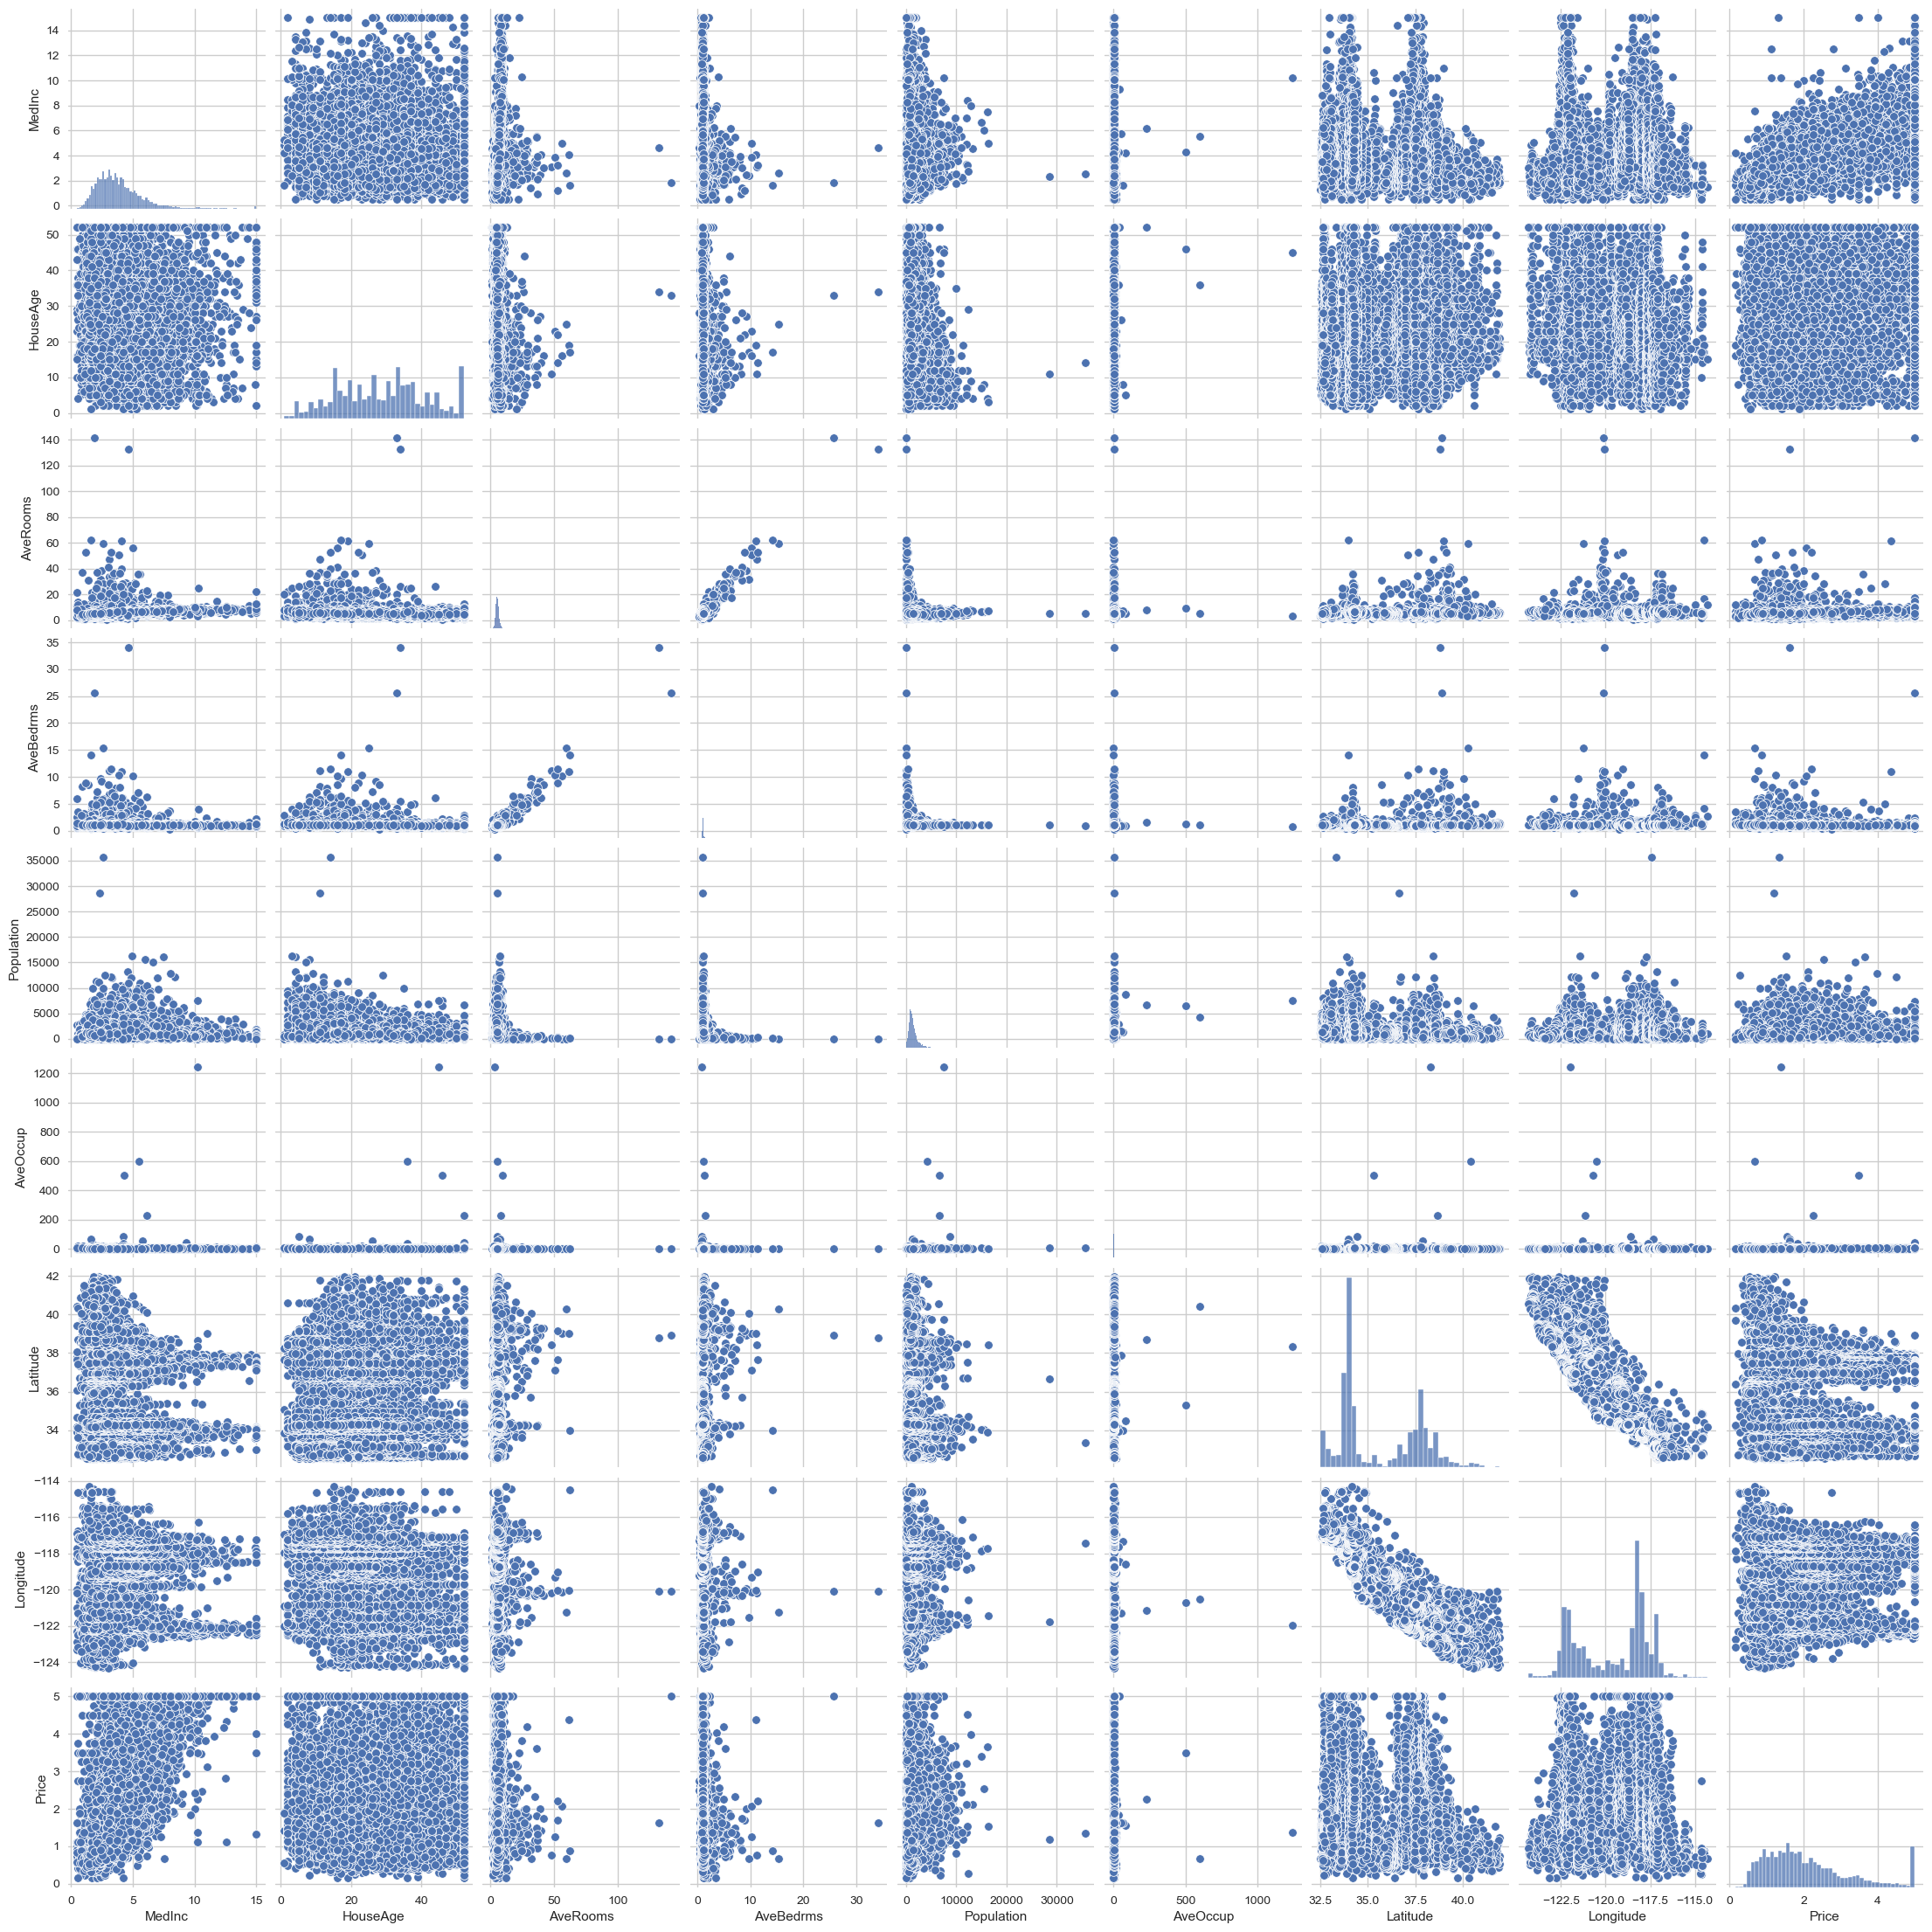

In [100]:
## check the relationship between each feature
sns.pairplot(df)

In [101]:
## We can see the numeric relationships witht the correlation
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


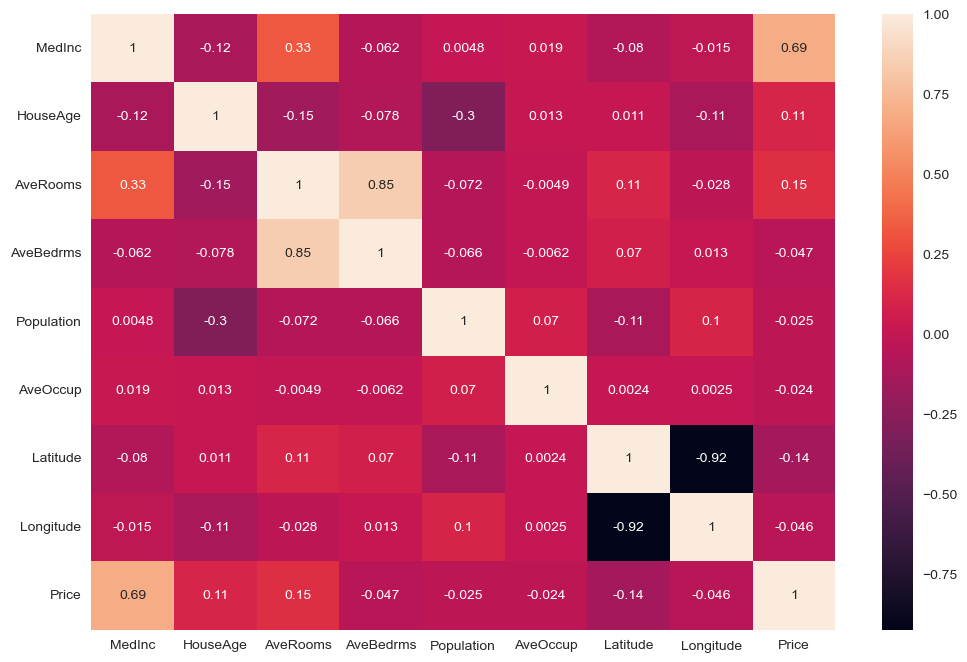

In [102]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [103]:
## Independent and Dependent features
X=df.iloc[:,:-1] ## independent
y=df.iloc[:,-1] ## dependent

In [104]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [105]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

In [106]:
## SPlit data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=10)

In [107]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((13828, 8), (6812, 8), (13828,), (6812,))

In [108]:
## Standardize the features using standard scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



In [109]:
## Model Training
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)

LinearRegression()

In [110]:
regression.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [111]:
regression.intercept_

2.0634768086491184

In [112]:
y_test_pred=regression.predict(X_test_scaled)

In [113]:
## Performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse=mean_squared_error(y_test,y_test_pred)
mae=mean_absolute_error(y_test,y_test_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_test_pred)

## Adjusted r-square
adjusted_score=1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1)

mse,mae,rmse,score, adjusted_score

(0.5522332399363619,
 0.537105694300796,
 0.7431239734636219,
 0.593595852643664,
 0.5931179409607519)

The r2_score is poor. We have to take necessary measures to improve the model

#### Assumptions

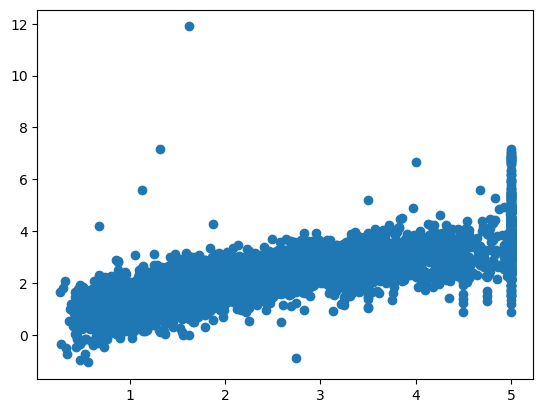

In [78]:
## Check y_test against y_pred
plt.scatter(y_test, y_test_pred)

C:\Users\pc\AppData\Local\Temp\ipykernel_21476\1332521333.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Price', ylabel='Density'>

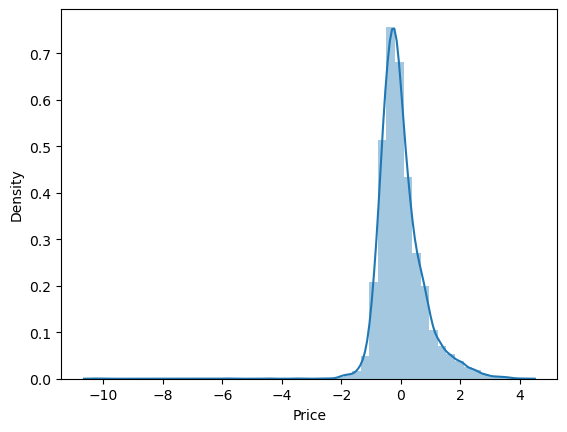

In [80]:
## check the distribution of the residuals

residuals = y_test-y_test_pred
sns.distplot(residuals, kde=True)

It looks normally distributed

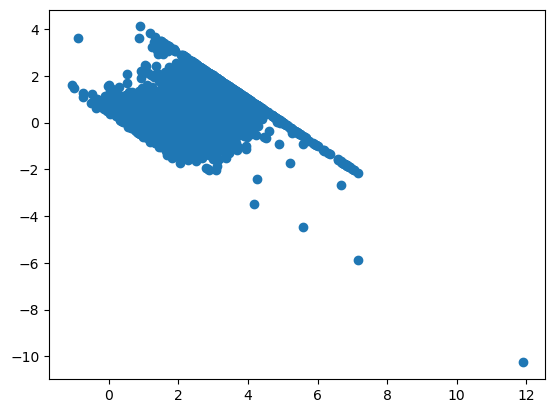

In [81]:
## plot the y_pred against the residuals
plt.scatter(y_pred,residuals)

It does not have a uniform distribution(No relationship/pattern). The relations ship looks linear

### Deployment technique

#### Pickling
Python pickle module is used for serialising and de-serialising a Python object structure. Any object in Python can be pickled so that it can be saved on disk. What pickle does is that it 'serialises' the object first before writing it to file. Pickling is a way to convert a python object (list,dict,etc) into a character stream. The idea is that this character stream contains all the information necessary to reconstruct the object in another python script.

This helps us to store things like the model we trained in a disk, so that when we deploy it to the cloud we can get the input and output

In [82]:
## import pickle library
import pickle
pickle.dump(regression,open('regression.pkl','wb')) ##it will store the regression model in a file we create called regresson.pkl
## we use the write-bite(wb) mode

In [83]:
## to load the pickle file
model = pickle.load(open('regression.pkl','rb'))

In [84]:
model.predict(X_test_scaled)

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

You can see we stored the regression model in a file and we recovered it and used it to make prediction. This is brilliant

# Ridge, Lasso, Elasticnet End-to-End

### Algerian Forest Fires Dataset

The dataset includes 244 instances that regroup a data of two regions of Algeria, namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attributes and 1 output attribute (class)
The 244 instances have been classified into fire (138 classes) and not fire (106 classes) classes.

1. Day: The day
2. Month: The Month
3. Year: The Year 2012
4. Temperature: Temperature noon (temperature max) in Celsius degrees: 22 to 42
5. RH: Relative Humidity in %: 21 to 90
6. Ws: Wind speed in km/h: 6 to 29
7. Rain: Total day in mm: 0 to 16.8
8. FFMC: Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
9. DMC: Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
10. DC: Drought Code (DC) index from the FWI system: 7 to 220.4
11. ISI: Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
12. BUI: Buildup Index (BUI) index from the FWI system: 1.1 to 68
13. FWI: Fire Weather Index (FWI) Index: 0 to 31.1
14. Classes: two classes, namely fire and not fire.



***Since we are doing linear regression we will try to predict the temperature (target feature) using the other labels (independent features)***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
dataset=pd.read_csv('ALgerian_forest_fires_dataset.csv')
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.1+ KB


In [5]:
## Check missing values

dataset[dataset.isnull().any(axis=1)] ## We are checking if there are null values in any column

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [6]:
dataset.drop(index=122, inplace=True)

In [7]:
dataset.loc[:123,'Region']=0
dataset.loc[123:, 'Region']=1
## We needed to create a region column so we can separate the two parts of the data
## the data is divided into 2. The 'Sidi-Bel Abbes Region Dataset' is the second region

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 38.9+ KB


In [9]:
dataset[['Region']]=dataset[['Region']].astype(int)

In [10]:
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [11]:
dataset = dataset.dropna().reset_index(drop=True)
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [12]:
dataset.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [13]:
## Fix white spaces in column names
dataset.columns=dataset.columns.str.strip()
dataset.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [14]:
## There is a column containing headers within the data. It was the headers for the second regions data
dataset[dataset['month'] == 'month']

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [15]:
dataset = dataset.drop(index=122).reset_index(drop=True)
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [16]:
## Lets convert the required columns as Integer datatype
dataset[['month','day','year','Temperature','RH','Ws']]=dataset[['month','day','year','Temperature','RH','Ws']].astype(int)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int32 
 1   month        243 non-null    int32 
 2   year         243 non-null    int32 
 3   Temperature  243 non-null    int32 
 4   RH           243 non-null    int32 
 5   Ws           243 non-null    int32 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int32 
dtypes: int32(7), object(8)
memory usage: 22.0+ KB


In [17]:
## changing the other columns to float datatype

objects=[features for features in dataset.columns if dataset[features].dtypes=='O']
## These are the columns with object type
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [18]:
for i in objects:
    if i!='Classes':
        dataset[i]=dataset[i].astype(float)

## this will convert all the dataset columns in the objects list except 'Classes'

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int32  
 1   month        243 non-null    int32  
 2   year         243 non-null    int32  
 3   Temperature  243 non-null    int32  
 4   RH           243 non-null    int32  
 5   Ws           243 non-null    int32  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int32  
dtypes: float64(7), int32(7), object(1)
memory usage: 22.0+ KB


In [19]:
dataset['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [20]:
dataset['Classes']=np.where(dataset['Classes'].str.contains('not fire'),0,1)

In [21]:
dataset['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [22]:
## let us save the cleaned dataset
dataset.to_csv('Algerian_forest_fires_cleaned_dataset_complete.csv')

### Exploratory Data Analysis

In [23]:
df=dataset.copy()
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [24]:
df.drop(['day','month','year'], axis=1, inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


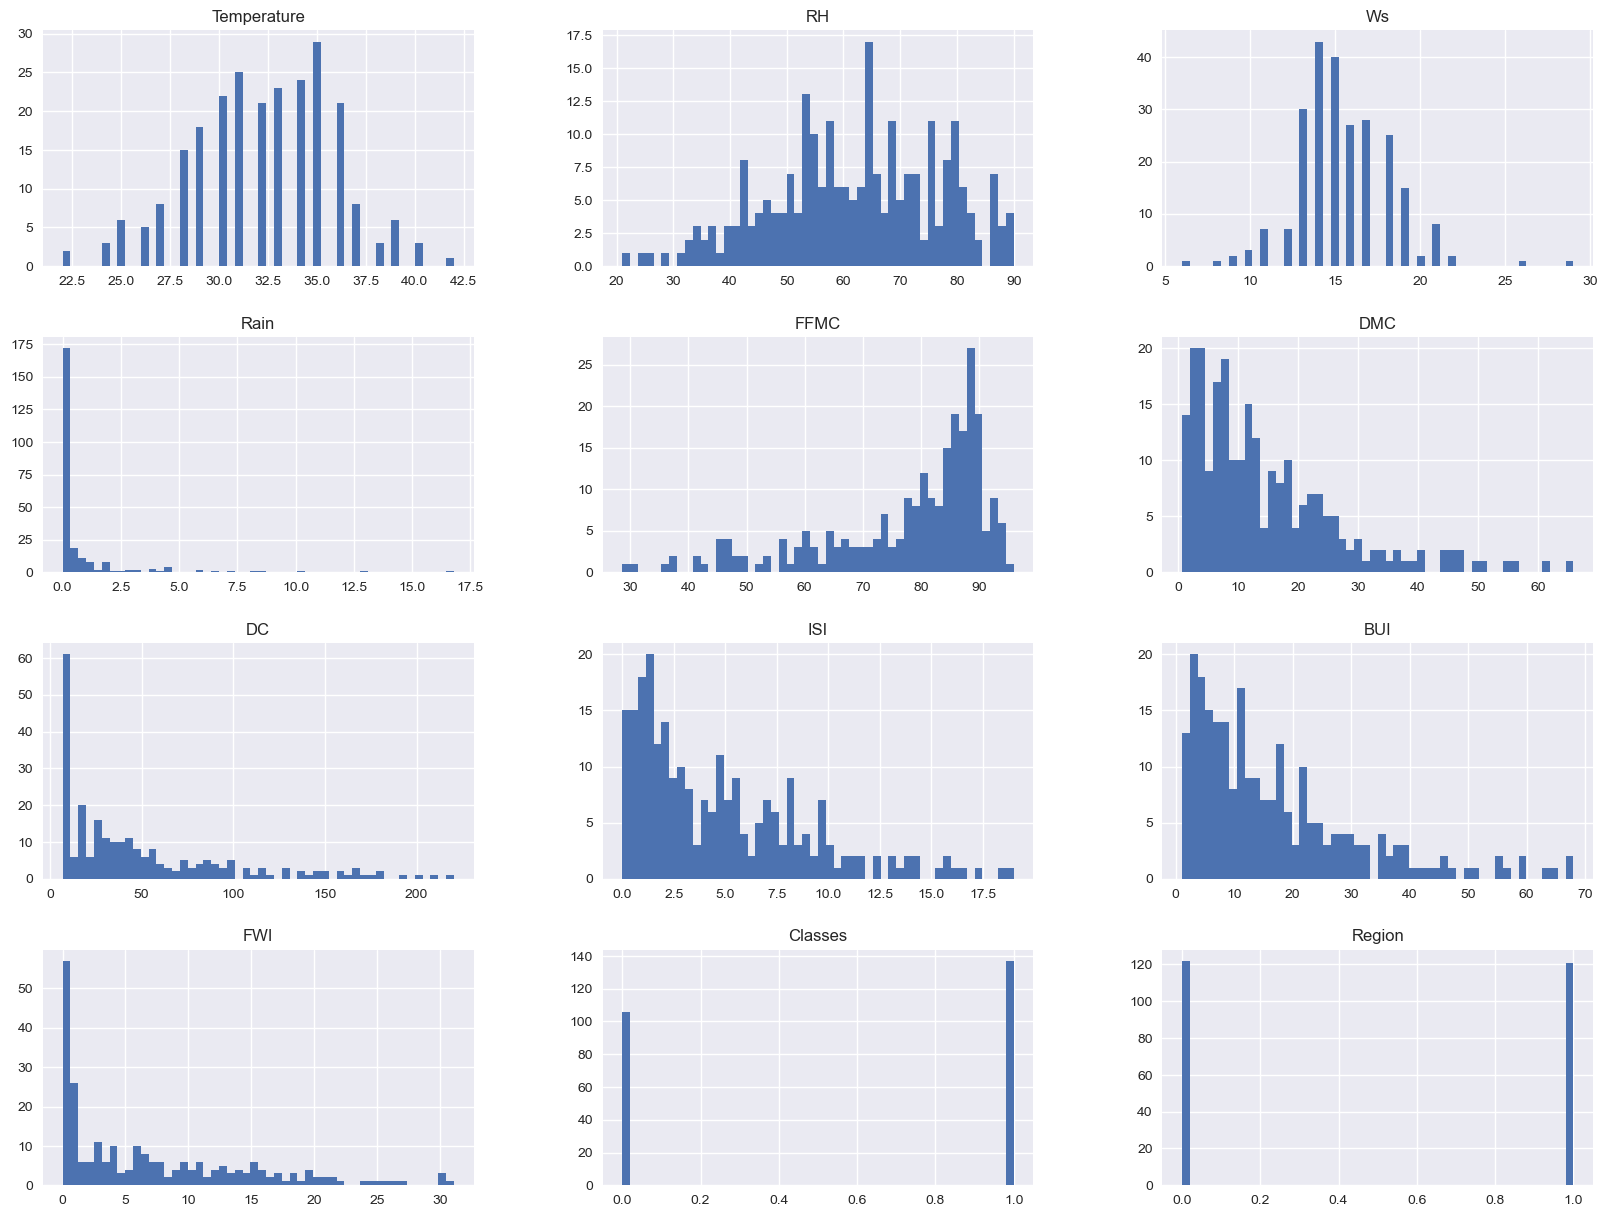

In [25]:
plt.style.use('seaborn-v0_8')
df.hist(bins=50,figsize=(20,15))
plt.show()

In [26]:
## Percentage for Pie Chart
percentage=df['Classes'].value_counts(normalize=True)*100 ## we are going to get the percentages

In [27]:
percentage=percentage.round(2)
percentage

Classes
1    56.38
0    43.62
Name: proportion, dtype: float64

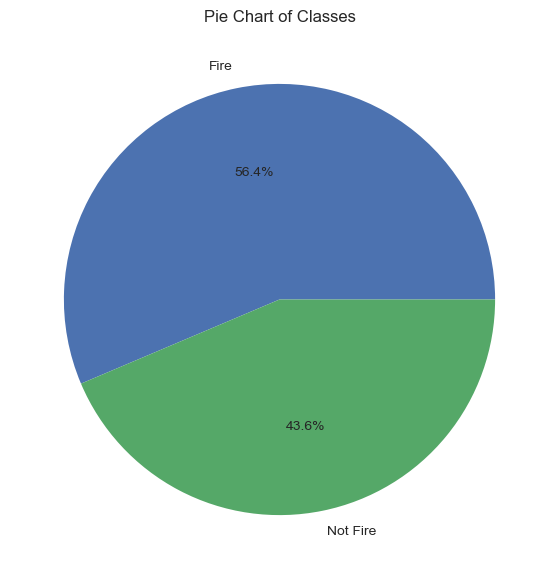

In [28]:
# plotting piechart
classlabels=['Fire','Not Fire']
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Pie Chart of Classes')
plt.show()

In [29]:
## Correlation
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

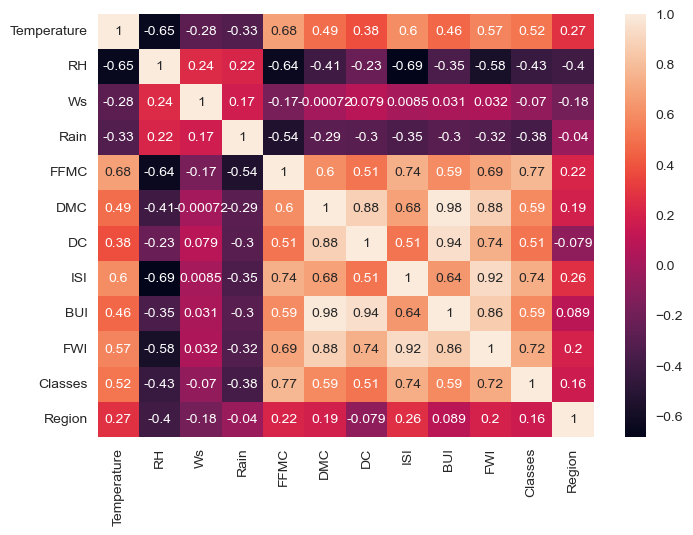

In [30]:
## The heatmap
sns.heatmap(df.corr(), annot=True)

<Axes: ylabel='Temperature'>

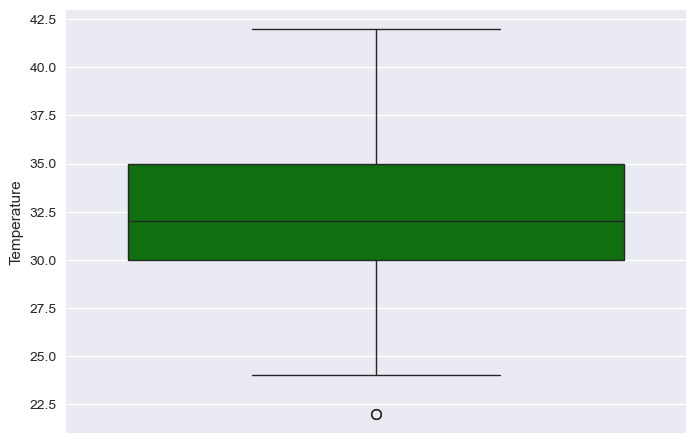

In [31]:
## Boxplots

sns.boxplot(df['Temperature'], color='green')

Text(0.5, 1.0, 'Fire Analysis of Sidi-Bel Regions')

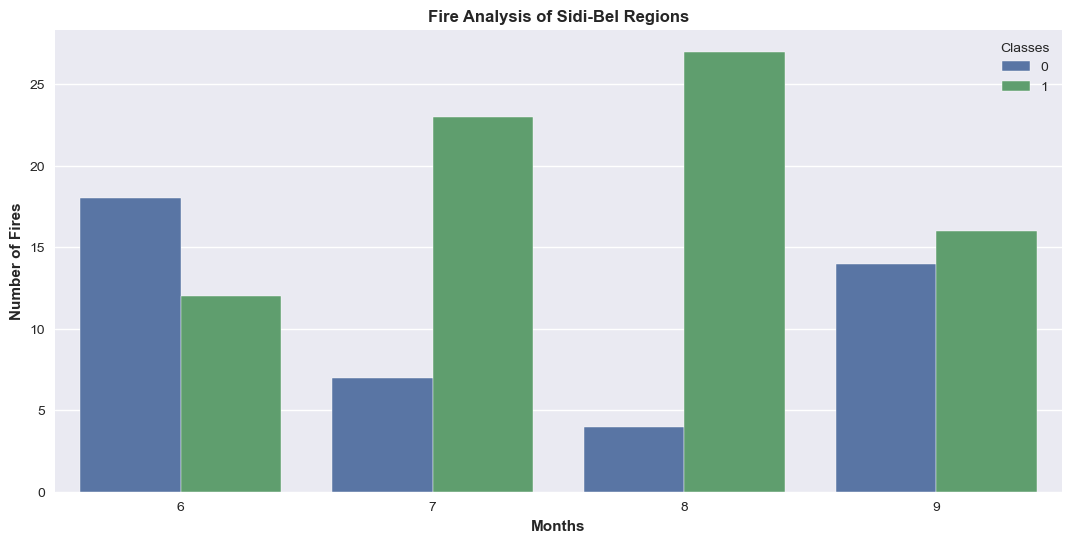

In [32]:
## Monthly Fire Analysis by Region
## We will use dataset not df_copy, because we dropped the month

dftemp=dataset.loc[dataset['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dftemp)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Sidi-Bel Regions', weight='bold')

## Study this 


Text(0.5, 1.0, 'Fire Analysis of Bejaia Regions')

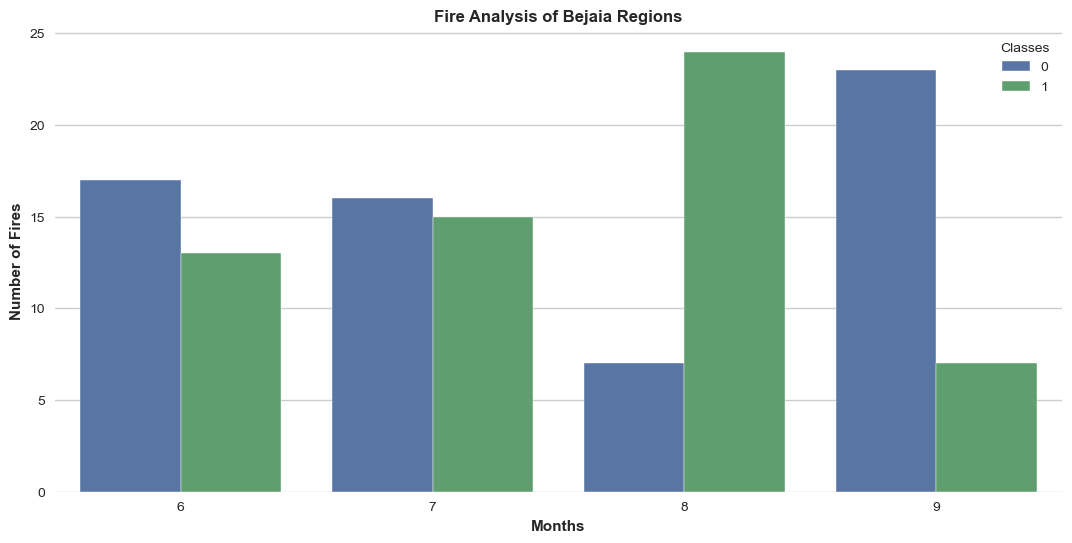

In [33]:
dftemp=dataset.loc[dataset['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dftemp)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis of Bejaia Regions', weight='bold')

Text(0.5, 1.0, 'Fire Analysis per Month')

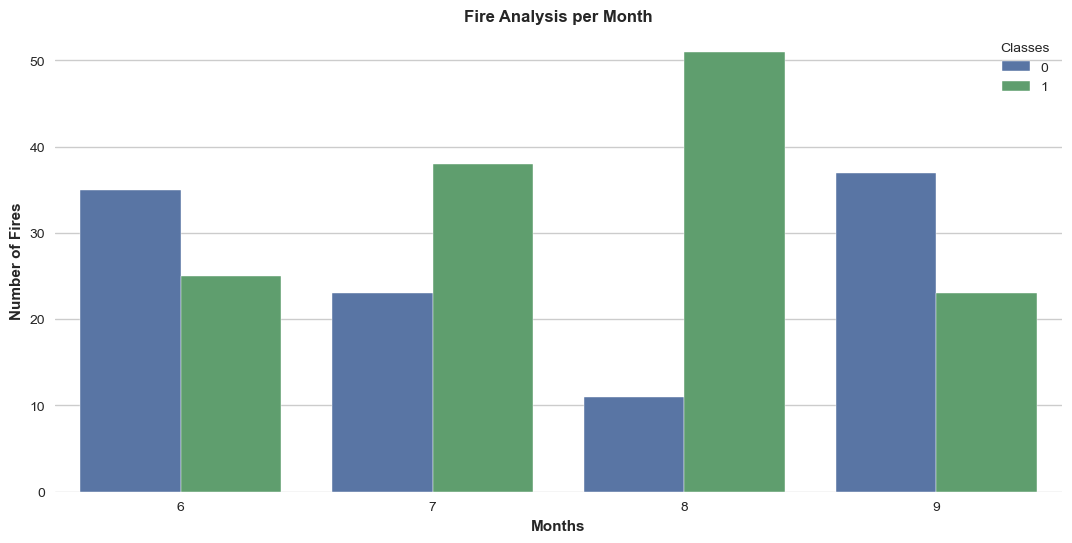

In [34]:
## In both regions combined
dftemp=dataset.loc[dataset['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes', data=dataset)
plt.ylabel('Number of Fires', weight='bold')
plt.xlabel('Months', weight='bold')
plt.title('Fire Analysis per Month', weight='bold')


### Model Training

In [35]:
## We will use the cleaned dataset
clean_df= pd.read_csv('Algerian_forest_fires_cleaned_dataset_complete.csv')
clean_df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [36]:
## We forgot to not include the index in the cleaned data wen we saved it. Now it is coming in as a new column
## We have to drop the unwanted column eg 'Unnamed: 0'

clean_df.drop(columns=['month','day','year','Unnamed: 0'], axis=1, inplace=True)
clean_df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [37]:
clean_df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

Recall this time we are taking Temerature as the target variable

In [38]:
clean_df['Temperature'].dtypes

dtype('int64')

In [39]:
## Independent and dependent features
X=clean_df.iloc[:,1:]
X.shape


(243, 11)

In [40]:
y=clean_df['Temperature']
y.shape

(243,)

In [41]:
## check multicollinearity.
## This means if two independent features are highly correlated we will have to drop one of them

X.corr()

,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
RH,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102
Classes,-0.432161,-0.069964,-0.379097,0.769492,0.585658,0.511123,0.735197,0.586639,0.719216,1.000000,0.162347


In [42]:
## We will set a threshold for this exercise eg 0.85
## Note: this threshold is determined by the DOMAIN EXPERT
## For now we will use 0.90
## Let us improve the below

def correlation(dataset, threshold):
    col_corr = set()
    col_pair = set()
    
    corr_matrix = dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname1 = corr_matrix.columns[i]
                colname2 = corr_matrix.columns[j]

                col_pair.add((colname1, colname2, corr_matrix.iloc[i, j]))
                col_corr.add(colname1)

    return col_corr, col_pair


In [43]:
## We will use the correlation() function we created.
## This will identify features that are highly correlated to each other
correlated_features,column_pairs =correlation(X,0.85)
correlated_features, column_pairs

## The column pairing is good for investigative purposes

({'BUI', 'DC', 'FWI'},
 {('BUI', 'DC', 0.9419884631009655),
  ('BUI', 'DMC', 0.9822484890812936),
  ('DC', 'DMC', 0.8759246606759622),
  ('FWI', 'BUI', 0.8579730958964258),
  ('FWI', 'DMC', 0.8758641588191531),
  ('FWI', 'ISI', 0.9228949343157855)})

In [44]:
## from the highly correlated pairs we need to decide which is best to drop from the data
## Suggestion: Compare with their correlation with the target. The one with less correlation to the target is removed from the features

clean_df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


#### Feature Correlation Analysis

Our goal now is:

1. Find features that are highly correlated with each other
2. Keep the feature that has a stronger correlation with `Temperature`
3. Drop the weaker/redundant feature

---

#### Highly Correlated Feature Pairs

| Feature Pair | Inter-correlation |
|---|---|
| BUI & DC | 0.94 |
| BUI & DMC | 0.98 |
| DC & DMC | 0.88 |
| FWI & BUI | 0.86 |
| FWI & DMC | 0.88 |
| FWI & ISI | 0.92 |

---

#### Correlation with Temperature

| Feature | Correlation with Temperature |
|---|---|
| DMC | 0.485 |
| DC | 0.376 |
| BUI | 0.459 |
| FWI | 0.566 |
| ISI | 0.604 |

---

#### Analysis

##### BUI vs DC

- BUI = 0.460
- DC = 0.376

Since `BUI` has a stronger correlation with `Temperature`, we keep `BUI` and drop `DC`.

---

##### BUI vs DMC

- DMC = 0.486
- BUI = 0.460

Since `DMC` has a slightly stronger correlation with `Temperature`, we keep `DMC` and drop `BUI`.

---

##### FWI vs ISI

- ISI = 0.604
- FWI = 0.567

Since `ISI` has a stronger correlation with `Temperature`, we keep `ISI` and drop `FWI`.

---

#### Final Feature Removals

```python
features_to_drop = ['DC', 'BUI', 'FWI']
```

In [45]:
features_to_drop = ['DC', 'BUI', 'FWI']

X=X.drop(features_to_drop, axis=1)
X.head()

,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
0,57,18,0.0,65.7,3.4,1.3,0,0
1,61,13,1.3,64.4,4.1,1.0,0,0
2,82,22,13.1,47.1,2.5,0.3,0,0
3,89,13,2.5,28.6,1.3,0.0,0,0
4,77,16,0.0,64.8,3.0,1.2,0,0


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [47]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((182, 8), (61, 8), (182,), (61,))

In [48]:
## Lets scale independent the features
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linreg=LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred=linreg.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Mean Squared error: ', mse)
print("Mean absolute error: ", mae)
print("Root mean sqauared error: ", rmse)
print('R2 score: ', score)

Mean Squared error:  6.339735428378812
Mean absolute error:  2.07277162967601
Root mean sqauared error:  2.5178831244477595
R2 score:  0.44579815982245086


### Ridge, Lasso, ElasticNet

In [50]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge=Ridge()
ridge.fit(X_train_scaled, y_train)

y_pred=ridge.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Ridge Mean Squared error: ', mse)
print("Ridge Mean absolute error: ", mae)
print("Ridge Root mean sqauared error: ", rmse)
print('Ridge R2 score: ', score)

Ridge Mean Squared error:  6.3162429756071266
Ridge Mean absolute error:  2.069150846133556
Ridge Root mean sqauared error:  2.513213674880655
Ridge R2 score:  0.4478518039695034


In [51]:
lasso=Lasso()
lasso.fit(X_train_scaled, y_train)

y_pred=lasso.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Lasso Mean Squared error: ', mse)
print("Lasso Mean absolute error: ", mae)
print("Lasso Root mean sqauared error: ", rmse)
print('Lasso R2 score: ', score)

Lasso Mean Squared error:  6.526166015862152
Lasso Mean absolute error:  2.133660267664301
Lasso Root mean sqauared error:  2.5546361807236178
Lasso R2 score:  0.4295009222143714


In [52]:
elasticnet=ElasticNet()
elasticnet.fit(X_train_scaled, y_train)

y_pred=elasticnet.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Ridge Mean Squared error: ', mse)
print("Ridge Mean absolute error: ", mae)
print("Ridge Root mean sqauared error: ", rmse)
print('Ridge R2 score: ', score)

Ridge Mean Squared error:  6.270067929530141
Ridge Mean absolute error:  2.0437711479844483
Ridge Root mean sqauared error:  2.504010369293654
Ridge R2 score:  0.4518882966268465


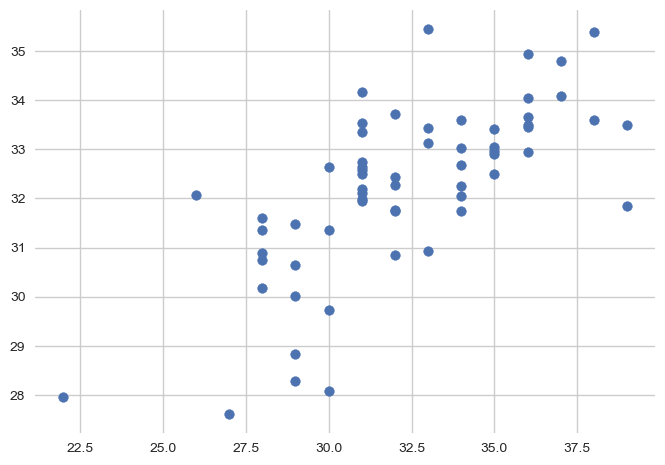

In [53]:
plt.scatter(y_test,y_pred)

This is a very poor model. The relationship between y_test and y_pred is not linear. We might have to check out cross validation and polynomial regressio 

In [56]:
## Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [60]:
poly=PolynomialFeatures(degree=2, include_bias=True)

X_train_poly= poly.fit_transform(X_train_scaled)
X_test_poly= poly.transform(X_test_scaled)

linreg=LinearRegression()
linreg.fit(X_train_poly, y_train)

y_pred=linreg.predict(X_test_poly)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Mean Squared error: ', mse)
print("Mean absolute error: ", mae)
print("Root mean sqauared error: ", rmse)
print('R2 score: ', score)


Mean Squared error:  7.873281209195246
Mean absolute error:  1.9470655097336065
Root mean sqauared error:  2.8059367792584435
R2 score:  0.3117399008735726


This is very poor. If we increase the degree of the polynomial it goes to negative which suggest a lot. At this point we can say the features are bad, for this prediction. We will drop the features with very low correlaton to Temperature to see if the model can be improved.

We will drop any model that has a correlation less than 0.6


In [62]:
def features_to_drop(dataset, threshold):
    col_to_drop = set()
    corr_matrix = dataset.corr()

    for col in corr_matrix.columns:
        # Skip target itself
        if col != 'Temperature':
            corr_value = corr_matrix['Temperature'][col]
            if abs(corr_value) < threshold:
                col_to_drop.add(col)
    return col_to_drop

In [63]:
columns_to_drop=features_to_drop(clean_df,0.6)
columns_to_drop

{'BUI', 'Classes', 'DC', 'DMC', 'FWI', 'Rain', 'Region', 'Ws'}

In [64]:
adjusted_df=clean_df.drop(columns=['BUI', 'Classes', 'DC', 'DMC', 'FWI', 'Rain', 'Region', 'Ws'],axis=1)
adjusted_df.head()

,Temperature,RH,FFMC,ISI
0,29,57,65.7,1.3
1,29,61,64.4,1.0
2,26,82,47.1,0.3
3,25,89,28.6,0.0
4,27,77,64.8,1.2


In [66]:
## Independent and dependent features
X=adjusted_df.iloc[:,1:]
X.shape

(243, 3)

In [68]:
y=adjusted_df['Temperature']
y.shape

(243,)

In [69]:
adjusted_df.corr()

,Temperature,RH,FFMC,ISI
Temperature,1.000000,-0.651400,0.676568,0.603871
RH,-0.651400,1.000000,-0.644873,-0.686667
FFMC,0.676568,-0.644873,1.000000,0.740007
ISI,0.603871,-0.686667,0.740007,1.000000


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [71]:
## Lets scale independent the features
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [72]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((182, 3), (61, 3), (182,), (61,))

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linreg=LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred=linreg.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Mean Squared error: ', mse)
print("Mean absolute error: ", mae)
print("Root mean sqauared error: ", rmse)
print('R2 score: ', score)

Mean Squared error:  6.04301456032026
Mean absolute error:  2.0260788355491215
Root mean sqauared error:  2.4582543725823536
R2 score:  0.4717366635589041


Not much has changed. We will visit this again. We have a poor model. Lets try polynomial model

In [77]:
## Lets apply polynomial transformation degree = 2
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2, include_bias=True)

X_train_poly= poly.fit_transform(X_train_scaled)
X_test_poly= poly.transform(X_test_scaled)

linreg=LinearRegression()
linreg.fit(X_train_poly, y_train)

y_pred=linreg.predict(X_test_poly)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Mean Squared error: ', mse)
print("Mean absolute error: ", mae)
print("Root mean sqauared error: ", rmse)
print('R2 score: ', score)

Mean Squared error:  5.556165225883637
Mean absolute error:  1.949891129415649
Root mean sqauared error:  2.357151931014129
R2 score:  0.5142956630758584


In [82]:
## Lets apply polynomial transformation degree = 3
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=3, include_bias=True)

X_train_poly= poly.fit_transform(X_train_scaled)
X_test_poly= poly.transform(X_test_scaled)

linreg=LinearRegression()
linreg.fit(X_train_poly, y_train)

y_pred=linreg.predict(X_test_poly)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)

print('Mean Squared error: ', mse)
print("Mean absolute error: ", mae)
print("Root mean sqauared error: ", rmse)
print('R2 score: ', score)

Mean Squared error:  4.930944170385614
Mean absolute error:  1.8668701802150205
Root mean sqauared error:  2.220572937416291
R2 score:  0.5689507292673761


The performance improved a little at degree = 3. Lets try removing the bias

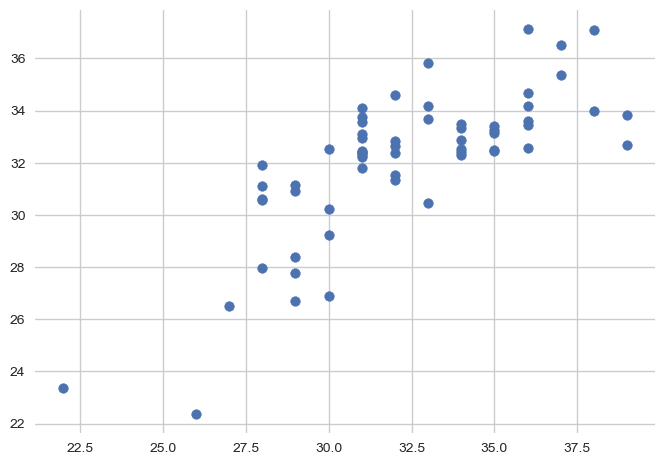

In [83]:
plt.scatter(y_test,y_pred)

The linearity improved but still not good enough. Let us investigate the relationship between each independent feature and target feature

Text(0.5, 1.0, 'RH vs Temperature')

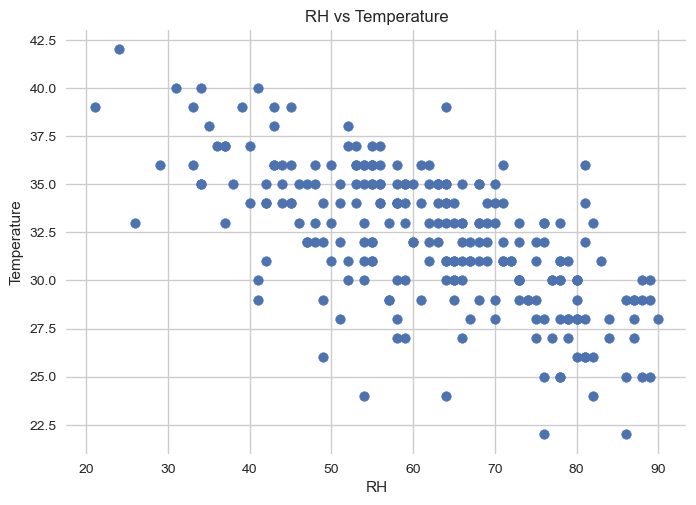

In [85]:
## RH vs Temperature
plt.scatter(adjusted_df['RH'],adjusted_df['Temperature'])
plt.xlabel('RH')
plt.ylabel('Temperature')
plt.title('RH vs Temperature')


Text(0.5, 1.0, 'FFMC vs Temperature')

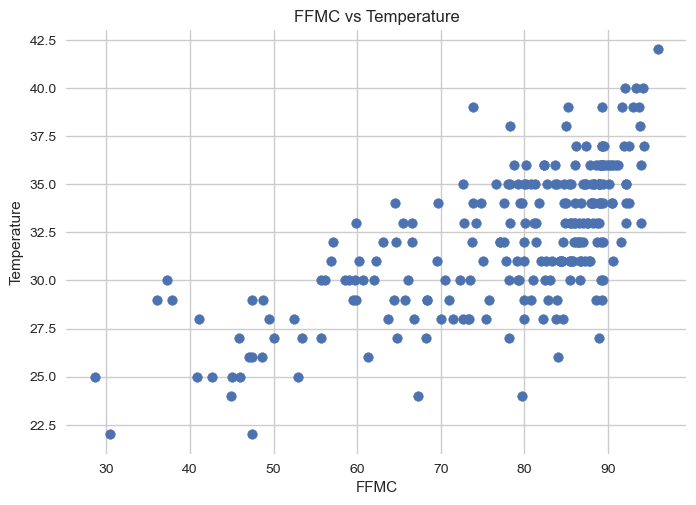

In [86]:
## FFMC vs Temperature
plt.scatter(adjusted_df['FFMC'],adjusted_df['Temperature'])
plt.xlabel('FFMC')
plt.ylabel('Temperature')
plt.title('FFMC vs Temperature')

Text(0.5, 1.0, 'ISI vs Temperature')

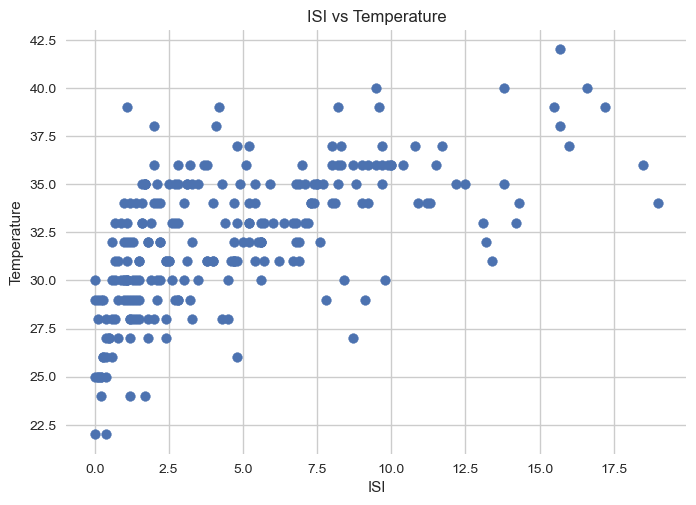

In [87]:
## ISI vs Temperature
plt.scatter(adjusted_df['ISI'],adjusted_df['Temperature'])
plt.xlabel('ISI')
plt.ylabel('Temperature')
plt.title('ISI vs Temperature')

We will come back to this!!!